In [1]:
# loading the data

In [2]:
import sklearn

In [3]:
from sklearn.datasets import make_circles

In [4]:
nsamples = 1000

x, y = make_circles(n_samples=nsamples, noise=0.03, random_state=42)

In [5]:
len(x)

1000

In [6]:
x[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [7]:
import matplotlib.pyplot as plt


In [8]:
import pandas as pd
circles = pd.DataFrame({'x1': x[:, 0], 'x2':x[:, 1], 'label': y})

In [9]:
circles.head(10)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


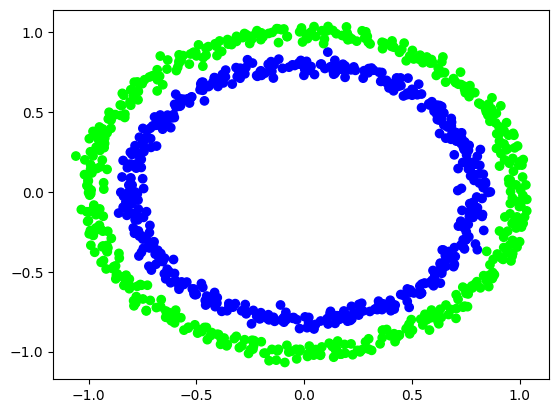

In [10]:
plt.scatter (x=x[:,0],y=x[:, 1],
c= y,
cmap=plt.cm.brg_r) 

In [11]:
x.shape
x.dtype

dtype('float64')

# data into tensors

In [12]:
import torch

In [13]:
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [14]:
x[:5], y[:4]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1.]))

# splitting data

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
len(xtrain),  len(xtest)

(800, 200)

# buiding the model

In [ ]:
import torch
from torch import nn

class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1= nn.Linear(in_features=2, out_features=50)
        self.layer2 = nn.Linear(in_features=50, out_features=50)
        self.layer3 = nn.Linear(in_features=50, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.layer3(x)
        return x
    

model0 = CircleModelV0()
model0

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=20, bias=True)
  (layer2): Linear(in_features=20, out_features=20, bias=True)
  (layer3): Linear(in_features=20, out_features=1, bias=True)
  (relu): ReLU()
)

In [19]:
# model0 = nn.Sequential(
#     nn.Linear(in_features=2, out_features=5),
#     nn.Linear(in_features=5, out_features=1)
# )

In [20]:
model0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.2476,  0.4111],
                      [-0.7026,  0.6683],
                      [-0.2268, -0.2985],
                      [ 0.5361,  0.1347],
                      [-0.3213,  0.6671],
                      [-0.1540, -0.3740],
                      [-0.4823,  0.1666],
                      [-0.6544,  0.4249],
                      [ 0.6229, -0.4739],
                      [-0.5985, -0.1096],
                      [ 0.2475,  0.3507],
                      [ 0.3063, -0.0925],
                      [ 0.5581,  0.6432],
                      [ 0.0309,  0.5474],
                      [-0.2359,  0.1686],
                      [-0.3837, -0.2061],
                      [ 0.3124, -0.4012],
                      [-0.3705,  0.4582],
                      [-0.3226,  0.2064],
                      [-0.3399,  0.3206]])),
             ('layer1.bias',
              tensor([ 0.3142,  0.2780, -0.6030, -0.6635,  0.5725, -0.6723,  0.4406,  0.2877,
   

In [21]:
with torch.inference_mode():   
    untrainedpreds = model0(xtest)
    print(len(untrainedpreds))

200


In [22]:
untrainedpreds[:5]

tensor([[0.0882],
        [0.0802],
        [0.1098],
        [0.0848],
        [0.0879]])

In [23]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.1)

In [24]:
def accuracyfn(ytrue, ypred):
    correct = torch.eq(ytrue,ypred).sum().item()
    acc = 100* correct/len(ypred)
    return acc

In [25]:
ypredprobs= torch.sigmoid(untrainedpreds)

In [26]:
torch.round(ypredprobs[:5])

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [27]:
accuracyfn(ytest, ypred=ypredprobs)

0.0

In [28]:
epochs =500

for epoch in range(epochs):
    model0.train()
    ylogits = model0(xtrain,).squeeze()
    ypred = torch.round(torch.sigmoid(ylogits))

    #calculate loss
    loss= loss_fn(ylogits, ytrain)
    acc= accuracyfn(ytrue=ytrain, ypred=ypred)

    optimizer.zero_grad()
    loss.backward()


    optimizer.step()

    model0.eval()
    with torch.inference_mode():
        testlogits = model0(xtest).squeeze()
        testpreds = torch.round(torch.sigmoid(testlogits))

        testloss = loss_fn(testlogits, ytest)


        testacc = accuracyfn(ytrue=ytest, ypred=testpreds)
        # testacc=0.0
    
    if epoch %10 == 0:
        print(f'epoch {epoch} | loss {loss:.5f} | acc {acc:.2f}% | test loss {testloss:.5f} | test acc: {testacc:.2f}%')


epoch 0 | loss 0.69608 | acc 50.00% | test loss 0.69480 | test acc: 50.00%
epoch 10 | loss 0.69484 | acc 50.00% | test loss 0.69349 | test acc: 50.00%
epoch 20 | loss 0.69399 | acc 50.00% | test loss 0.69261 | test acc: 50.00%
epoch 30 | loss 0.69340 | acc 59.00% | test loss 0.69204 | test acc: 59.50%
epoch 40 | loss 0.69277 | acc 55.12% | test loss 0.69145 | test acc: 56.50%
epoch 50 | loss 0.69223 | acc 50.25% | test loss 0.69098 | test acc: 54.50%
epoch 60 | loss 0.69185 | acc 51.00% | test loss 0.69063 | test acc: 54.50%
epoch 70 | loss 0.69155 | acc 51.00% | test loss 0.69036 | test acc: 54.50%
epoch 80 | loss 0.69131 | acc 50.62% | test loss 0.69012 | test acc: 55.00%
epoch 90 | loss 0.69109 | acc 50.88% | test loss 0.68990 | test acc: 55.00%
epoch 100 | loss 0.69085 | acc 51.00% | test loss 0.68965 | test acc: 55.00%
epoch 110 | loss 0.69059 | acc 51.88% | test loss 0.68937 | test acc: 55.00%
epoch 120 | loss 0.69033 | acc 52.38% | test loss 0.68913 | test acc: 55.00%
epoch 130 

In [29]:
testlogits = model0(xtest).squeeze()
testpreds = torch.round(torch.sigmoid(testlogits))

testloss = loss_fn(testlogits, ytest)


testacc = accuracyfn(ytrue=ytest, ypred=testpreds)
# testacc=0.0

if epoch %10 == 0:
    print(f'epoch {epoch} | loss {loss:.5f} | acc {acc:.2f}% | test loss {testloss:.5f} | test acc: {testacc:.2}%')

In [30]:
import requests
from pathlib import Path
# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path ("helper_functions.py"). is_file() :
    print( "helper_functions. py already exists, skipping download")
else:
    print(" Download helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open ("helper_functions.py", "wb") as f:
        f.write (request.content)



helper_functions. py already exists, skipping download


In [31]:
from helper_functions import plot_predictions, plot_decision_boundary

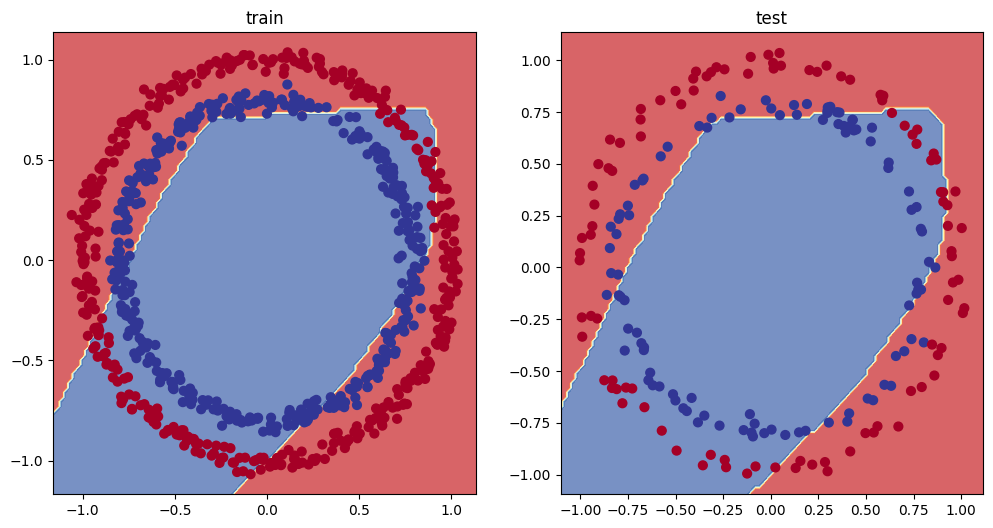

In [32]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model0, xtrain, ytrain)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model0, xtest, ytest)